# Questo codice serve ad eseguire più test di un modello, salvare le matrice A barra e M e printare le loro medie su sequenze che hanno il token speciale sempre nella stesso posizione.
### Nota: Usare la CPU

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/WillyPuri/my_mamba.git

from my_mamba.symple_induction_head_dataset import TokenInductionHeadDataset, Make_Tokenizer, From_Seq_To_Numb, print_sequence
#from my_mamba.patch_functions import patched_slow_save
from my_mamba.auxiliary_functions import parse_model_filename

import transformers
from transformers.models.mamba.modeling_mamba import MambaMixer, MambaCache
from transformers import MambaConfig, MambaForCausalLM

import torch
import torch.nn as nn

import os

import matplotlib.pyplot as plt

best_model_path = "/content/drive/MyDrive/mamba/best_models/"
BM_filename = "layers2_patchconvFalse_spacing1_spectoks1_vocabsize16.pt"

batch_size = 8
special_token = "A"
fix_indx = 7
sep_vocab = False

# Estraggo le variabili dal nome del file
parsed = parse_model_filename(BM_filename)
patch_conv1d = parsed["patch_conv1d"]
spacing = parsed["spacing"]
num_special_tokens = parsed["num_special_tokens"]
vocab_size = parsed["vocab_size"]

best_model_filename = os.path.join(best_model_path, BM_filename)
tokenizer = Make_Tokenizer(vocab_size)

Mounted at /content/drive
Cloning into 'my_mamba'...
remote: Enumerating objects: 161, done.
remote: Counting objects: 100% (161/161), done.
remote: Compressing objects: 100% (157/157), done.
remote: Total 161 (delta 51), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (161/161), 367.04 KiB | 4.59 MiB/s, done.
Resolving deltas: 100% (51/51), done.


In [2]:
import torch
# controlliamo se la GPU è disponibile e nel caso quale tipo di GPU
if torch.cuda.is_available():
  print('Numero di GPU disponibili: ',torch.cuda.device_count())
  for i in range(0,torch.cuda.device_count()):
    print(torch.cuda.get_device_name(i))

# se la GPU è disponibile setto device='cuda', altrimenti 'cpu
device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Computation device: {device}\n")

Computation device: cpu



In [3]:
from transformers.models.mamba.modeling_mamba import MambaMixer, MambaCache
from typing import Optional
import itertools
import os
import shutil

def patched_slow_save(self, input_states, cache_params: Optional[MambaCache]=None, cache_position:Optional[torch.LongTensor]=None, attention_mask: Optional[torch.LongTensor] = None):
        batch_size, seq_len, _ = input_states.shape
        dtype = input_states.dtype
        # 1. Gated MLP's linear projection
        projected_states = self.in_proj(input_states).transpose(1, 2)                   # [batch, 2 * intermediate_size, seq_len]
        hidden_states, gate = projected_states.chunk(2, dim=1)

        if attention_mask is not None:
            hidden_states = hidden_states * attention_mask.unsqueeze(1)

        # 2. Convolution sequence transformation
        if cache_params is not None:
            ssm_state = cache_params.ssm_states[self.layer_idx].clone()
            ssm_state = ssm_state.to(hidden_states.device)
            # use `cache_position.shape[0]` to check whether we are in prefill
            # stage, it's equivalent to check `cache_position[0] == 0`, which
            # breaks dynamo fullgraph constraints
            if cache_position.shape[0] == self.conv_kernel_size:
                conv_state = nn.functional.pad(
                    hidden_states,
                    (self.conv_kernel_size - hidden_states.shape[-1], 0)
                )

                cache_params.update_conv_state(self.layer_idx, conv_state, cache_position)
                hidden_states = self.act(self.conv1d(hidden_states)[..., :seq_len])     # [batch, intermediate_size, seq_len]
            else:
                conv_state = cache_params.update_conv_state(self.layer_idx, hidden_states, cache_position)
                conv_state = conv_state.to(self.conv1d.weight.device)
                hidden_states = torch.sum(conv_state * self.conv1d.weight[:, 0, :], dim=-1)
                if self.use_conv_bias:
                    hidden_states += self.conv1d.bias
                hidden_states = self.act(hidden_states).to(dtype).unsqueeze(-1)         # [batch, intermediate_size, 1] : decoding
        else:
            ssm_state = torch.zeros(
                (batch_size, self.intermediate_size, self.ssm_state_size),
                device=hidden_states.device, dtype=dtype
            )
            hidden_states = self.act(self.conv1d(hidden_states)[..., :seq_len])         # [batch, intermediate_size, seq_len]

        if attention_mask is not None:
            hidden_states = hidden_states * attention_mask.unsqueeze(1)

        # 3. State Space Model sequence transformation
        # 3.a. Selection:  [batch, seq_len, self.time_step_rank + self.ssm_state_size * 2]
        ssm_parameters = self.x_proj(hidden_states.transpose(1, 2))
        time_step, B, C = torch.split(
            ssm_parameters, [self.time_step_rank, self.ssm_state_size, self.ssm_state_size], dim=-1
        )
        discrete_time_step = self.dt_proj(time_step)                                    # [batch, seq_len, intermediate_size]
        discrete_time_step = nn.functional.softplus(discrete_time_step).transpose(1, 2) # [batch, intermediate_size, seq_len]

        # 3.b. Discretization: B and C to [batch, seq_len, intermediate_size, ssm_state_size] (SRAM)
        A = -torch.exp(self.A_log.float())                                              # [intermediate_size, ssm_state_size]
        discrete_A = torch.exp(A[None, :, None, :] * discrete_time_step[:, :, :, None]) # [batch, intermediate_size, seq_len, ssm_state_size]
        discrete_B = discrete_time_step[:, :, :, None] * B[:, None, :, :].float()       # [batch, intermediate_size, seq_len, ssm_state_size]
        deltaB_u = discrete_B * hidden_states[:, :, :, None].float()

        # 3.c perform the recurrence y ← SSM(A, B, C)(x)
        if self.use_mambapy and self.training and cache_params is None:
            hs = pscan(discrete_A.transpose(1, 2), deltaB_u.transpose(1, 2)) # [batch, seq_len, intermediate_size, ssm_state_size]

            scan_output = (hs @ C.unsqueeze(-1)).squeeze(3).transpose(1, 2) # [batch, intermediate_size, seq_len]
            scan_output = scan_output + hidden_states * self.D[None, :, None]
            scan_output = scan_output * self.act(gate)
        else:
            scan_outputs = []
            for i in range(seq_len):
                ssm_state = discrete_A[:, :, i, :] * ssm_state + deltaB_u[:, :, i, :]      # [batch, intermediate_size, ssm_state]
                scan_output = torch.matmul(ssm_state.to(dtype), C[:, i, :].unsqueeze(-1))  # [batch, intermediate_size, 1]
                scan_outputs.append(scan_output[:, :, 0])
            scan_output = torch.stack(scan_outputs, dim=-1)                                # [batch, intermediate_size, seq_len]
            scan_output = scan_output + (hidden_states * self.D[None, :, None])
            scan_output = (scan_output * self.act(gate))

            if cache_params is not None:
                cache_params.ssm_states[self.layer_idx].copy_(ssm_state)

        #--------------------------PARTE MODIFICATA------------------------
        # Contatori per salvare la matrice con un nome sensato
        layer_id = getattr(self, "layer_idx", 0)
        if layer_id == 0:
          global token_id
          token_id+=1

        # Salvo le matrici discrete_A, discrete_B e C per un layer fissato

        save_sub_dir_A = os.path.join(save_dir, f"A_bar/layer{layer_id}/")
        save_sub_dir_B = os.path.join(save_dir, f"B_bar/layer{layer_id}/")
        save_sub_dir_C = os.path.join(save_dir, f"C/layer{layer_id}/")
        save_sub_dir_D = os.path.join(save_dir, f"D/layer{layer_id}/")

        os.makedirs(save_sub_dir_A, exist_ok=True)
        os.makedirs(save_sub_dir_B, exist_ok=True)
        os.makedirs(save_sub_dir_C, exist_ok=True)
        os.makedirs(save_sub_dir_D, exist_ok=True)

        file_path_A = os.path.join(save_sub_dir_A, f"M_{token_id}.pt")
        file_path_B = os.path.join(save_sub_dir_B, f"M_{token_id}.pt")
        file_path_C = os.path.join(save_sub_dir_C, f"M_{token_id}.pt")
        file_path_D = os.path.join(save_sub_dir_D, f"M_{token_id}.pt")

        torch.save(discrete_A, file_path_A)
        torch.save(discrete_B, file_path_B)
        torch.save(C, file_path_C)
        torch.save(self.D, file_path_D)                 # self.D.size() = torch.Size([intermediate_size])

        #--------------------------PARTE MODIFICATA------------------------

        # 4. Final linear projection
        contextualized_states = self.out_proj(scan_output.transpose(1, 2))  # [batch, seq_len, hidden_size]
        return contextualized_states

In [4]:
MambaMixer.slow_forward = patched_slow_save

loaded_model = torch.load(best_model_filename, map_location=device)
config = MambaConfig(**loaded_model["config"])

model = MambaForCausalLM(config)

model.load_state_dict(loaded_model["model_state_dict"])
model.to(device)

print(config)
print(model)

The fast path is not available because one of `(selective_state_update, selective_scan_fn, causal_conv1d_fn, causal_conv1d_update, mamba_inner_fn)` is None. Falling back to the sequential implementation of Mamba, as use_mambapy is set to False. To install follow https://github.com/state-spaces/mamba/#installation for mamba-ssm and install the kernels library using `pip install kernels` or https://github.com/Dao-AILab/causal-conv1d for causal-conv1d. For the mamba.py backend, follow https://github.com/alxndrTL/mamba.py.


MambaConfig {
  "add_cross_attention": false,
  "bos_token_id": 0,
  "conv_kernel": 4,
  "cross_attention_hidden_size": null,
  "decoder_start_token_id": null,
  "eos_token_id": 0,
  "expand": 2,
  "finetuning_task": null,
  "hidden_act": "silu",
  "hidden_size": 64,
  "initializer_range": 0.1,
  "intermediate_size": 128,
  "is_decoder": false,
  "layer_norm_epsilon": 1e-05,
  "model_type": "mamba",
  "num_hidden_layers": 2,
  "pad_token_id": 0,
  "prefix": null,
  "pruned_heads": {},
  "rescale_prenorm_residual": false,
  "residual_in_fp32": true,
  "sep_token_id": null,
  "state_size": 16,
  "task_specific_params": null,
  "tf_legacy_loss": false,
  "tie_encoder_decoder": false,
  "tie_word_embeddings": true,
  "time_step_floor": 0.0001,
  "time_step_init_scheme": "random",
  "time_step_max": 0.1,
  "time_step_min": 0.001,
  "time_step_rank": 4,
  "time_step_scale": 1.0,
  "tokenizer_class": null,
  "torchscript": false,
  "transformers_version": "5.0.0",
  "use_bfloat16": false,
  "

In [5]:
import torch
from torch.utils.data import DataLoader, TensorDataset

import glob
import re

import matplotlib.pyplot as plt
import numpy as np

# Funzione per caricare i files in ordine cronologico
def extract_number(path):
    """Estrae il numero finale dal nome del file."""
    match = re.search(r'_(\d+)(?:\.\w+)?$', path)
    return int(match.group(1)) if match else -1

def attention_map_row(previous_row,A_bar_d,B_bar_d,C):                         # Si chiama Attention Map la matrice M_d
  partial_new_row = (A_bar_d * previous_row)
  diag = B_bar_d
  diag = torch.unsqueeze(diag,0)
  partial_new_row = torch.cat([partial_new_row,diag], dim=0)                   # [seq_len,ssm_state_dim]
  new_row = (C * partial_new_row).sum(dim=1)                                   # implemento il prodotto riga per colonna
  return partial_new_row,new_row

seq_len = 40
dataset_size = 1000

layer1_largest = []
layer2_largest = []

T = seq_len
M1 = torch.zeros(T, T)
M2 = torch.zeros(T, T)

all_columns = []

for k in range(dataset_size):
  dataset = TokenInductionHeadDataset(seq_len=seq_len, dataset_size=1, vocab_size= vocab_size, special_token=special_token, num_special_tokens = num_special_tokens,spacing=spacing, fix_indx=fix_indx,sep_vocab=sep_vocab)
  tokenizer = dataset.tokenizer
  data_ids, target_ids = From_Seq_To_Numb(tokenizer,dataset)

  tensor_dataset = TensorDataset(data_ids, target_ids)
  data_loader = DataLoader(tensor_dataset, batch_size=batch_size, shuffle=True)

  token_id = -1
  temp = None
  save_dir = "/content/M_matrices/"
  shutil.rmtree(save_dir, ignore_errors=True)
  os.makedirs(save_dir)

  model.eval()

  with torch.no_grad():
    for idx, (input_ids, target_ids) in enumerate(data_loader):
      input_ids = input_ids.to(device)
      target_ids = target_ids.to(device)
      target_ids = target_ids.squeeze(-1)

      outputs = model(input_ids)

      logits = outputs.logits
      last_logits = logits[:, -1, :]

      predictions = torch.argmax(last_logits, dim=-1)

      for j in range(input_ids.shape[0]):
        predictions_token = tokenizer.id_to_token(predictions[j].item())
        seq_tokens = [tokenizer.id_to_token(token_id.item()) for token_id in input_ids[j]]
        print_sequence(seq_tokens, seq_tokens[-1], spacing, predictions_token)


  all_largest = []
  rows1 = []
  rows2 = []

  for i in range(2):
    layer_id = i
    pattern = f"{save_dir}/A_bar/layer{layer_id}/M_*"

    paths = sorted(glob.glob(pattern), key=extract_number)

    product = 1
    largest = []

    for path in paths:
      big_A_bar = torch.load(path)

      big_A_bar = big_A_bar.squeeze(0)                                  # rimuovi la dim 0 che è banale
      big_A_bar.to(dtype=torch.float64)

      for j in range(big_A_bar.size(1)):                          # l'indice j corre sulla lunghezza della sequenza
        eigenvalues = big_A_bar[:,j,:].flatten()                  # per ogni j hai una matrice (channels,ssm_dim)

        product = product * eigenvalues
        largest_eigenvalue, _ = torch.max(product, dim=0) # Modified: extract only the value
        largest.append(largest_eigenvalue)

    largest = torch.stack(largest, dim=0)
    all_largest.append(largest)


  tot_largest = torch.stack(all_largest, dim=0)                             # [layers, token_gen]

  layer1_largest.append(tot_largest[0])
  layer2_largest.append(tot_largest[1])


  # Attention map
  for layer_id in range(2):
    partial = []
    new = []

    sub_dir_A = os.path.join(save_dir, f"A_bar/layer{layer_id}/")
    sub_dir_B = os.path.join(save_dir, f"B_bar/layer{layer_id}/")
    sub_dir_C = os.path.join(save_dir, f"C/layer{layer_id}/")

    file_path_A = os.path.join(sub_dir_A,f"M_{token_id}.pt")
    file_path_B = os.path.join(sub_dir_B,f"M_{token_id}.pt")
    file_path_C = os.path.join(sub_dir_C,f"M_{token_id}.pt")

    A_bar=torch.load(file_path_A)                                      # size: [batch, hidden_size, seq_len, ssm_size]
    B_bar=torch.load(file_path_B)                                      # size: [batch, hidden_size, seq_len, ssm_size]
    C=torch.load(file_path_C)                                          # size: [batch, seq_len, ssm_size]

    A_bar=A_bar.squeeze(0)                                             # size: [hidden_size, seq_len, ssm_size]
    B_bar=B_bar.squeeze(0)                                             # size: [hidden_size, seq_len, ssm_size]
    C=C.squeeze(0)                                                     # size: [seq_len, ssm_size]

    L = A_bar.size(1)                                              # Numero di tokens
    D = A_bar.size(0)                                              # Numero di canali

    prova=[]
    for l in range(L):
      for d in range(D):
        vec_A = A_bar[d,l,:]
        vec_B = B_bar[d,l,:]
        #vec_B = torch.ones_like(vec_B)
        vec_C = C[l,:]
        #print(torch.sign(torch.sum(vec_B)))

        if l == 0:
          partial.append(vec_B.unsqueeze(0))
          new.append((vec_C * partial[d]).sum(dim=1))
        else:
          partial[d], new[d] = attention_map_row(partial[d],vec_A,vec_B,vec_C)
      mean = sum(np.abs(new))/D

      if layer_id == 0:
        rows1.append(mean)

      else:
        rows2.append(mean)
      if l == 0:
        prova.append(A_bar[:,l,:].flatten())
      else:
        new_prova_element = A_bar[:,l,:].flatten() * prova[l-1]
        prova.append(new_prova_element)
      #print(len(prova[l]))

      #plt.hist(prova[l], bins=30, color='skyblue', edgecolor='black')
      #plt.show()

    #print(torch.cat(prova).shape)
  temp_M1 = torch.zeros(T, T)
  temp_M2 = torch.zeros(T, T)
  for t in range(T):
    temp_M1[t, :t+1] = torch.from_numpy(rows1[t])
    temp_M2[t, :t+1] = torch.from_numpy(rows2[t])

  if dataset_size ==1:
    M1+=temp_M1/dataset_size
    M2+=temp_M2/dataset_size
    column = temp_M1[:, fix_indx+1]
  else:
    M1+=torch.abs(temp_M1)/dataset_size
    M2+=torch.abs(temp_M2)/dataset_size
    column = torch.abs(temp_M1[:, fix_indx+1])

  all_columns.append(column)

F P E C B O D A C N P P M J M I C E L F O F E P F D F N K K L D H F J N B E C A
Target: C  Prediction: C  Result: True
P P I D J B L A F I N I O L B G I J P P I H H O G P P K L J D P B L D P C E E A
Target: F  Prediction: F  Result: True
K F L F L L K A P K J P D P C I I G F L F E H J H M B P L H P B H G E C F M C A
Target: P  Prediction: P  Result: True
J J G E C P N A L J J L L K K M O P B M F H N O K C E I B D G D I O C L L D P A
Target: L  Prediction: L  Result: True
F N B H L F D A J O B O O O O N L J C M E E K L L H C F L K N M H K G G L C P A
Target: J  Prediction: J  Result: True
C P N B H L I A F I J I D O P L D D J L I K B F O M D C J C P D K H F B L C H A
Target: F  Prediction: F  Result: True
P K C C J K C A C E B I D I G C I O M G G K C P G C L I O P P C E B L B C E P A
Target: C  Prediction: C  Result: True
H C K B H M G A N E D P J N O O O P D J N F J G E J C G D I O N D E E D D K N A
Target: N  Prediction: N  Result: True
C G D K E H B A N C P K N G P P J I M P E F C D 

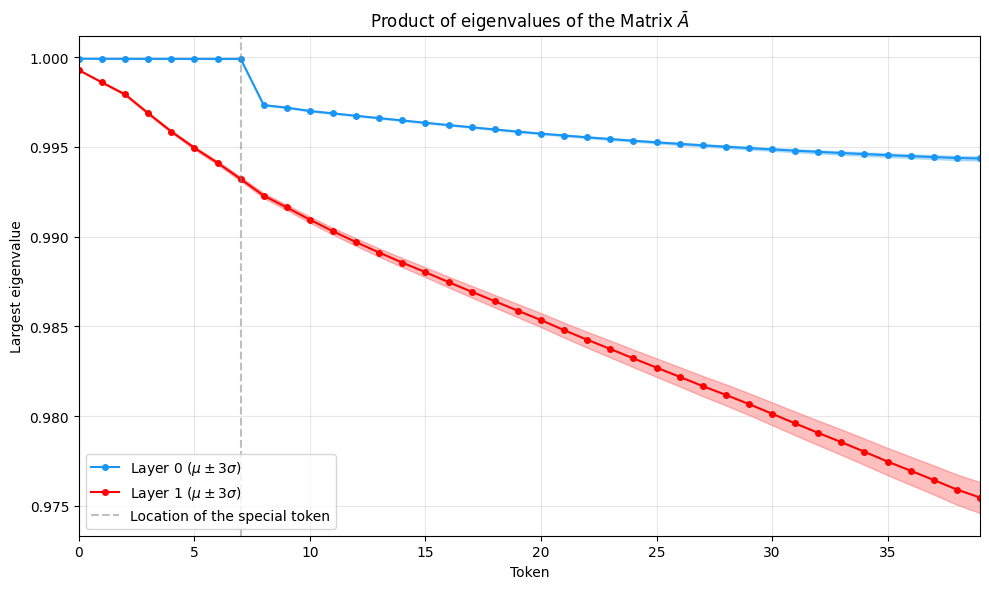

In [6]:
layer1_largest = np.array(layer1_largest)
media1 = np.mean(layer1_largest, axis=0)
std1 = np.std(layer1_largest, axis=0)/np.sqrt(dataset_size)

layer2_largest = np.array(layer2_largest)
media2 = np.mean(layer2_largest, axis=0)
std2 = np.std(layer2_largest, axis=0)/np.sqrt(dataset_size)

plt.figure(figsize=(10, 6))

cmap = plt.cm.rainbow
colors = cmap(np.linspace(0.2, 1, 2))

x = np.arange(len(media1))
# Layer 1
if dataset_size ==1:
  plt.plot(x, media1, color=colors[0], linestyle='-', marker='o', markersize=4, label=r'Layer 0')
else:
  plt.plot(x, media1, color=colors[0], linestyle='-', marker='o', markersize=4, label=r'Layer 0 ($\mu \pm 3\sigma$)')

plt.fill_between(
    x,
    media1 - 3*std1,
    media1 + 3*std1,
    color=colors[0],
    alpha=0.25
)

# Layer 2
if dataset_size ==1:
  plt.plot(x, media2, color=colors[1], linestyle='-', marker='o', markersize=4, label=r'Layer 1')
else:
  plt.plot(x, media2, color=colors[1], linestyle='-', marker='o', markersize=4, label=r'Layer 1 ($\mu \pm 3\sigma$)')
plt.fill_between(
    x,
    media2 - 3*std2,
    media2 + 3*std2,
    color=colors[1],
    alpha=0.25
)

plt.xlabel("Token")
plt.ylabel("Largest eigenvalue")
plt.xlim(0,tot_largest.shape[1]-1)
plt.title("Product of eigenvalues ​​of the Matrix $\\bar{A}$")
plt.grid(alpha=0.3)
plt.axvline(fix_indx,color='gray', linestyle='--',alpha=0.5,label='Location of the special token')
plt.legend(loc='lower left')
plt.tight_layout()
plt.savefig("average_largest_eignevalues.png")
plt.show()

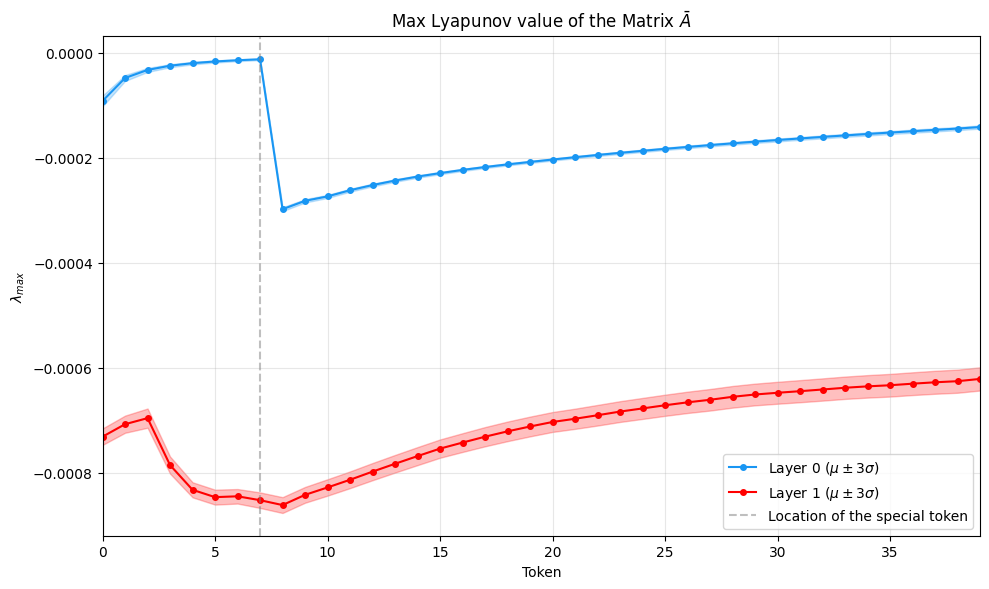

In [7]:
plt.figure(figsize=(10, 6))

cmap = plt.cm.rainbow
colors = cmap(np.linspace(0.2, 1, 2))

lyapunov1 = np.log(media1)
lstd1 = std1/np.abs(media1)

for j in range(lyapunov1.shape[0]):
  lyapunov1[j]/= j+1
  lstd1[j]/= j+1

if dataset_size ==1:
  plt.plot(lyapunov1, color=colors[0], linestyle='-', marker='o', markersize=4, label=r'Layer 0')
else:
  plt.plot(lyapunov1, color=colors[0], linestyle='-', marker='o', markersize=4, label=r'Layer 0 ($\mu \pm 3\sigma$)')

plt.fill_between(
    x,
    lyapunov1 - 3*lstd1,
    lyapunov1 + 3*lstd1,
    color=colors[0],
    alpha=0.25
)

lyapunov2 = np.log(media2)
lstd2 = std2/np.abs(media2)

for j in range(lyapunov2.shape[0]):
  lyapunov2[j]/= j+1
  lstd2[j]/= j+1

if dataset_size ==1:
  plt.plot(lyapunov2, color=colors[1], linestyle='-', marker='o', markersize=4, label=r'Layer 1')
else:
  plt.plot(lyapunov2, color=colors[1], linestyle='-', marker='o', markersize=4, label=r'Layer 1 ($\mu \pm 3\sigma$)')
plt.fill_between(
    x,
    lyapunov2 - 3*lstd2,
    lyapunov2 + 3*lstd2,
    color=colors[1],
    alpha=0.25
)

plt.xlim(0,tot_largest.shape[1]-1)
plt.xlabel("Token")
plt.ylabel("$\\lambda_{max}$")
plt.title("Max Lyapunov value ​​of the Matrix $\\bar{A}$")
plt.grid(alpha=0.3)
plt.axvline(fix_indx,color='gray', linestyle='--',alpha=0.5,label='Location of the special token')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("average_max_lyapunov.png")
plt.show()

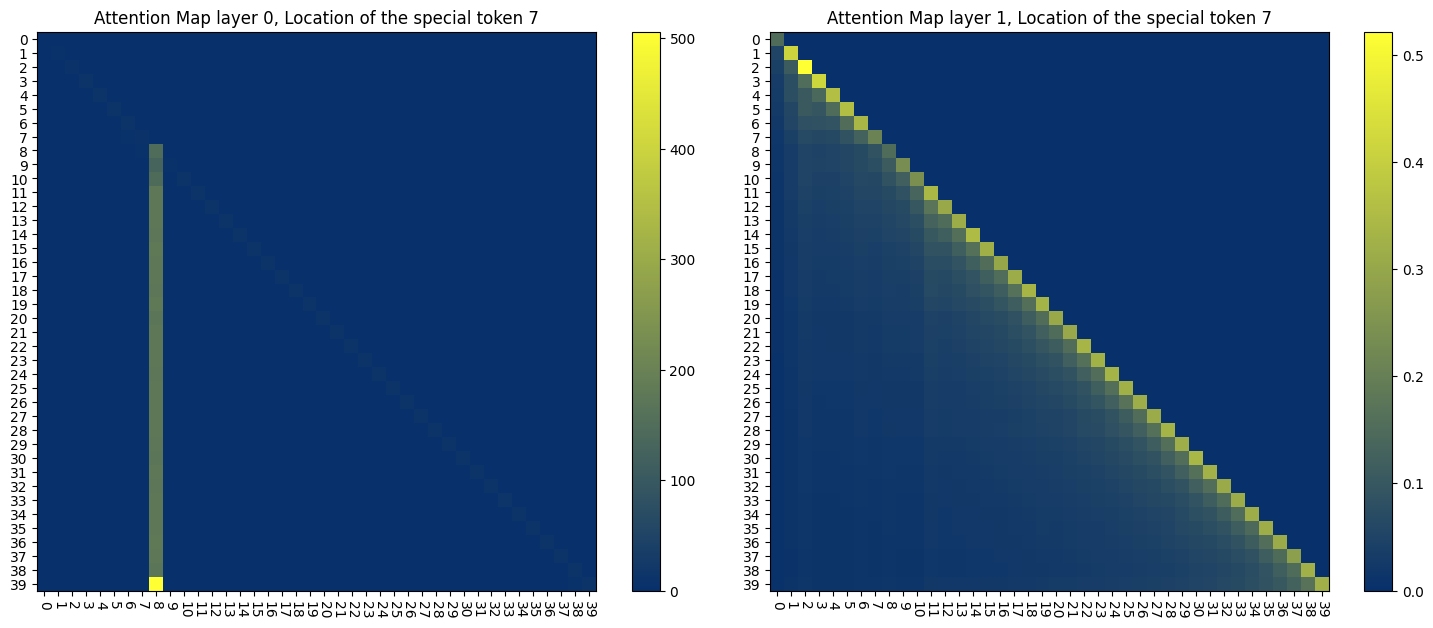

In [8]:
from matplotlib.colors import TwoSlopeNorm
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as ticker

if dataset_size ==1:
  cmap = LinearSegmentedColormap.from_list(
      "cyan_darkblue_yellow",
      [
          "#41b6c4",  # ciano
          "#08306b",  # blu scuro
          "#ffff33"   # giallo
      ],
      N=256
  )
else:
  cmap = LinearSegmentedColormap.from_list(
    "darkblue_yellow",
    [
        "#08306b",  # blu scuro
        "#ffff33"   # giallo
    ],
    N=256
)


m1 = torch.abs(M1).max().item()
m2 = torch.abs(M2).max().item()

if dataset_size ==1:
  norm1 = TwoSlopeNorm(vmin=-m1, vcenter=0.0, vmax=m1)
  norm2 = TwoSlopeNorm(vmin=-m2, vcenter=0.0, vmax=m2)
else:
  norm1 = TwoSlopeNorm(vmin=0, vcenter=m1/2, vmax=m1)
  norm2 = TwoSlopeNorm(vmin=0, vcenter=m2/2, vmax=m2)


fig, axes = plt.subplots(1, 2, figsize=(15, 6))
plt.setp(axes[0].get_xticklabels(), rotation=-90)
# Plot on the appropriate subplot
im = axes[0].imshow(M1.numpy(), cmap=cmap, norm=norm1)
axes[0].set_title(f"Attention Map layer {0}, Location of the special token {fix_indx}")
axes[0].xaxis.set_major_locator(ticker.MultipleLocator(1))
axes[0].yaxis.set_major_locator(ticker.MultipleLocator(1))
plt.setp(axes[0].get_xticklabels(), rotation=-90)
fig.colorbar(im, ax=axes[0])

plt.setp(axes[1].get_xticklabels(), rotation=-90)
# Plot on the appropriate subplot
im = axes[1].imshow(M2.numpy(), cmap=cmap, norm=norm2)
axes[1].set_title(f"Attention Map layer {1}, Location of the special token {fix_indx}")
axes[1].xaxis.set_major_locator(ticker.MultipleLocator(1))
axes[1].yaxis.set_major_locator(ticker.MultipleLocator(1))
plt.setp(axes[1].get_xticklabels(), rotation=-90)
fig.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.savefig("average_attention_Maps_combined.png")
plt.show()

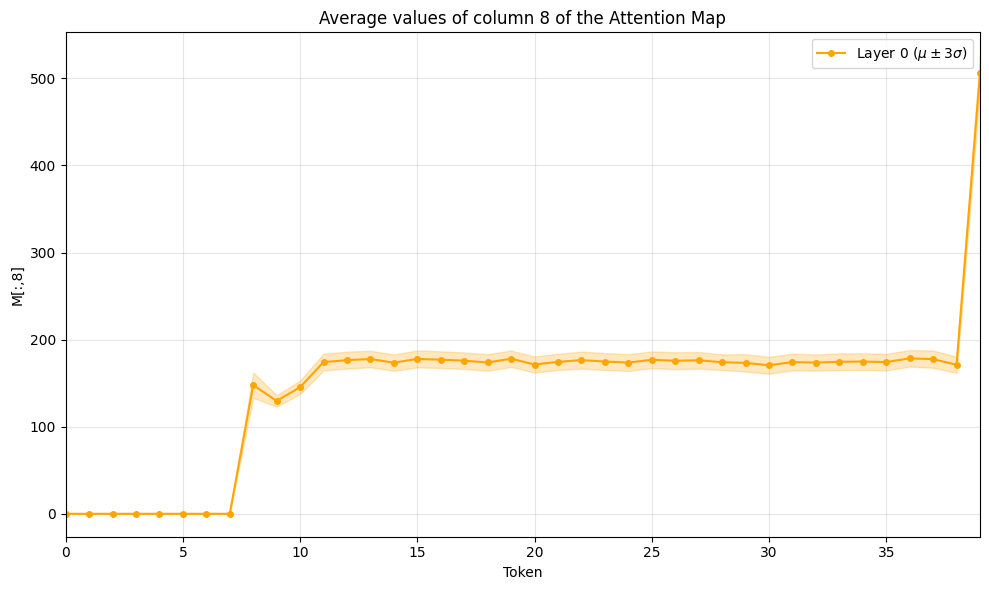

In [9]:
mean_column = np.mean(all_columns, axis=0)
std_column = np.std(all_columns, axis=0)/np.sqrt(dataset_size)

plt.figure(figsize=(10, 6))
x = np.arange(len(media1))
# Layer 1
if dataset_size ==1:
  plt.plot(x, mean_column, color='orange', linestyle='-', marker='o', markersize=4, label=r'Layer 0')
else:
  plt.plot(x, mean_column, color='orange', linestyle='-', marker='o', markersize=4, label=r'Layer 0 ($\mu \pm 3\sigma$)')
plt.fill_between(
    x,
    mean_column - 3*std_column,
    mean_column + 3*std_column,
    color='orange',
    alpha=0.25
)

plt.xlabel("Token")
plt.ylabel(f"M[:,{fix_indx+1}]")
plt.xlim(0,tot_largest.shape[1]-1)
plt.title(f"Average values ​​of column {fix_indx+1} of the Attention Map")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.legend()
plt.savefig("average_column.png")
plt.show()

### Riproduco un suono che indica la fine del codice

In [10]:
import numpy as np
from IPython.display import Audio, display

# Parametri del suono
frequency = 1000
duration = 1
sampling_rate = 44100

t = np.linspace(0, duration, int(sampling_rate * duration), endpoint=False)
wave = 0.5 * np.sin(2 * np.pi * frequency * t)

display(Audio(wave, rate=sampling_rate, autoplay=True))
